[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/da380/PartIIStatistics/blob/main/notebooks/09_inverse_problems.ipynb)

# 9. Inverse problems (optional)

**What you should get out of this notebook**

- Understand the difference between fitting a few parameters and inferring a function from finite data.
- See why an inverse problem can have no unique answer even with error-free data, and what the null space is.
- Know what minimum-norm and damped (regularised) solutions are, and that each is a *choice*.
- Understand resolution: an estimate is a blurred version of the truth, and the blurring can be computed.
- See how the Bayesian view turns regularisation into a prior, and gives honest uncertainties through posterior samples.

**Tools introduced**

- `np.linalg.svd`, `np.linalg.matrix_rank`, `np.linalg.pinv`, `np.linalg.solve`
- `np.random.multivariate_normal` (through `rng.multivariate_normal`) for posterior samples
- the `pygeoinf` library (optional final section) for the same tomography in function space

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd

rng = np.random.default_rng(1)          # random number generator with a fixed seed
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
DATA = "https://raw.githubusercontent.com/da380/PartIIStatistics/main/data/"

*This notebook is optional and a little more advanced than the others. It assumes Notebooks 5 and 7.*

## Forward and inverse problems

Much of geophysics consists of inferring something you cannot see from measurements made at a distance: the Earth's interior from seismic travel times, density from gravity, a thermal history from isotope ratios, past climate from proxies. In each case the physics gives a **forward problem**: given the model, predict the data. The **inverse problem** is the reverse, and it is where the difficulty lies.

We have already solved inverse problems of a kind. Fitting a straight line (Notebook 5) infers two parameters from fifty data. The situation there was *overdetermined*: more data than unknowns, so the difficulty was to reconcile inconsistent data, and the answer was unique. In most geophysical problems the unknown is a *function*, seismic velocity at every point in the Earth, say, which has infinitely many degrees of freedom, while the data are finite in number. Such problems are **underdetermined**: infinitely many models predict exactly the same data. The central message of this notebook is that

> **an underdetermined inverse problem has no unique solution even when the data are exact.** What we call "the solution" is always a choice, and the choice should be made consciously and stated.

Everything below is for **linear** problems, where the data depend linearly on the model: $\mathbf{d} = \mathbf{G}\mathbf{m} + \mathbf{e}$, with $\mathbf{m}$ the vector of model parameters, $\mathbf{G}$ a known matrix from the physics, and $\mathbf{e}$ the data errors. Nonlinear problems are usually attacked by repeated linearisation, so the ideas carry over.

## A toy tomography problem

A square block of rock is divided into $N \times N$ cells, each with an unknown **slowness** (the reciprocal of seismic velocity). Straight rays cross the block from sources to receivers, and we measure the travel time of each ray, which is the sum over the cells it crosses of the path length in the cell times the slowness there:

$$
t_k = \sum_{j} G_{kj}\, m_j, \qquad G_{kj} = \text{length of ray } k \text{ in cell } j .
$$

This is a miniature version of seismic tomography. The function below builds $\mathbf{G}$ for any set of straight rays by sampling each ray finely and accumulating the length in each cell. We start with a very sparse experiment: one horizontal and one vertical ray through each row and column of cells.

24 rays, 144 unknowns;  G has shape (24, 144)


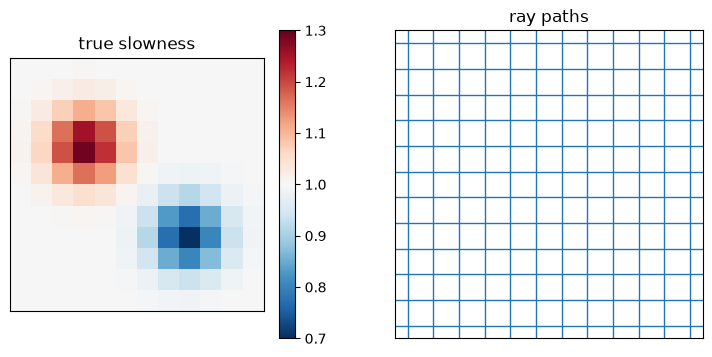

In [ ]:
N = 12                                   # the block is N x N cells on the unit square
M = N * N                                # number of model parameters (cell slownesses)

def ray_matrix(rays, N, n_pts=4000):
    """Rows: rays, columns: cells (index i + N*j for column i, row j). Entries: path length in cell."""
    G = np.zeros((len(rays), N * N))
    for k, ((x0, y0), (x1, y1)) in enumerate(rays):
        t = (np.arange(n_pts) + 0.5) / n_pts
        x, y = x0 + t * (x1 - x0), y0 + t * (y1 - y0)
        i = np.minimum((x * N).astype(int), N - 1)
        j = np.minimum((y * N).astype(int), N - 1)
        np.add.at(G, (k, i + N * j), np.hypot(x1 - x0, y1 - y0) / n_pts)
    return G

def show(m, ax, title="", cmap="RdBu_r", **kw):
    """Plot a model vector as an image of the block."""
    im = ax.imshow(m.reshape(N, N), origin="lower", extent=(0, 1, 0, 1), cmap=cmap, **kw)
    ax.set(title=title, xticks=[], yticks=[]); return im

c = (np.arange(N) + 0.5) / N
rays = [((0, yc), (1, yc)) for yc in c] + [((xc, 0), (xc, 1)) for xc in c]     # N horizontal + N vertical rays
G = ray_matrix(rays, N)
print(f"{len(rays)} rays, {M} unknowns;  G has shape {G.shape}")

# A "true" slowness model: uniform background with a slow blob and a fast blob
X, Y = np.meshgrid(c, c)
m_true = (1.0 + 0.3 * np.exp(-((X - 0.3)**2 + (Y - 0.65)**2) / 0.02)
              - 0.3 * np.exp(-((X - 0.7)**2 + (Y - 0.3)**2) / 0.02)).ravel()
d_exact = G @ m_true                                                          # error-free travel times

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
im = show(m_true, ax[0], "true slowness", vmin=0.7, vmax=1.3); plt.colorbar(im, ax=ax[0])
for (x0, y0), (x1, y1) in rays:
    ax[1].plot([x0, x1], [y0, y1], "C0", lw=1)
ax[1].set(title="ray paths", xlim=(0, 1), ylim=(0, 1), aspect="equal", xticks=[], yticks=[])
plt.show()

## Non-uniqueness and the null space

With 24 travel times and 144 unknowns we clearly cannot determine every cell. But the situation is worse than "not enough equations": the equations we have are not even independent. The sum of the horizontal travel times equals the sum of the vertical ones (both are the total slowness times the cell size), so only 23 of the 24 data carry independent information.

The **singular value decomposition** (SVD), $\mathbf{G} = \mathbf{U}\mathbf{S}\mathbf{V}^T$, is the tool for seeing this. The columns of $\mathbf{V}$ are orthonormal directions in model space; each is mapped by $\mathbf{G}$ onto the corresponding column of $\mathbf{U}$, scaled by its singular value $s_i$. The number of non-zero singular values is the **rank** of $\mathbf{G}$, the number of independent pieces of information in the data. The remaining directions in model space form the **null space**: models that produce *no data at all*. Adding any null-space model to a solution leaves the predicted data unchanged.

rank of G = 23;  null space has dimension 121
singular values: [0.408 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.289
 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.289 0.   ]

largest |travel-time| produced by a null-space model: 6.9e-18


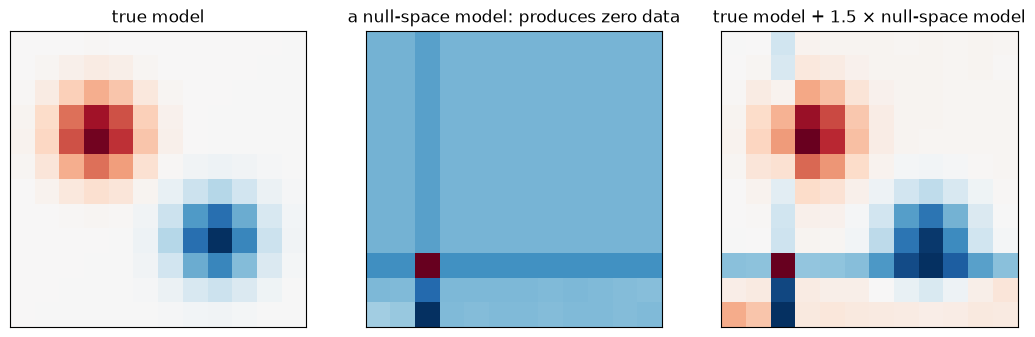

maximum difference in predicted travel times between left and right models: 2.2e-16


In [ ]:
U, s, Vt = np.linalg.svd(G)
rank = np.linalg.matrix_rank(G)
print(f"rank of G = {rank};  null space has dimension {M - rank}")
print("singular values:", np.round(s, 3))

null_space = Vt[rank:]                     # rows are orthonormal null-space models
z = null_space[3]                          # any one of them (or any combination)
print(f"\nlargest |travel-time| produced by a null-space model: {np.abs(G @ z).max():.1e}")

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
show(m_true, ax[0], "true model", vmin=0.7, vmax=1.3)
show(z, ax[1], "a null-space model: produces zero data")
show(m_true + 1.5 * z, ax[2], "true model + 1.5 × null-space model", vmin=0.7, vmax=1.3)
plt.show()
print(f"maximum difference in predicted travel times between left and right models: {np.abs(G @ m_true - G @ (m_true + 1.5*z)).max():.1e}")

The models on the left and right predict *identical* travel times, to machine precision, yet one is smooth and the other is riddled with structure. No amount of measurement precision can distinguish them: the difference between them is invisible to this experiment. A 121-dimensional family of models fits the data exactly, and the data cannot tell them apart.

This is the sense in which the inverse problem "has no answer". It is not a matter of noise or of insufficient care. It follows from the geometry of the experiment, and the only cures are more (or better placed) data or extra information from outside the data.

## Picking a solution: the minimum-norm estimate

If we must choose one model from the family that fits the data, we need a criterion. The most common default is the **minimum-norm** solution: of all models that fit the data, the one with the smallest $\|\mathbf{m}\|$ (or, after subtracting a reference model, the one closest to it). It contains no null-space component, since adding one could only increase the norm. It is computed with the **pseudo-inverse** $\mathbf{G}^{+} = \mathbf{V}\mathbf{S}^{-1}\mathbf{U}^T$, inverting only the non-zero singular values.

data misfit of minimum-norm model: 2.2e-16
norm of perturbation: minimum-norm 0.747,  true model 0.902


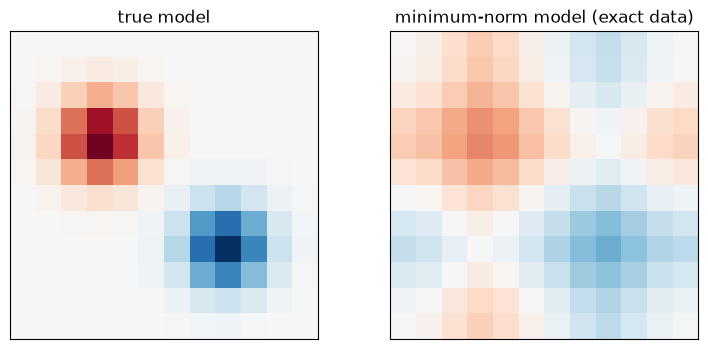

In [ ]:
m0 = np.ones(M)                                        # reference model: uniform slowness 1
m_mn = m0 + np.linalg.pinv(G) @ (d_exact - G @ m0)     # minimum-norm perturbation about the reference

print(f"data misfit of minimum-norm model: {np.abs(G @ m_mn - d_exact).max():.1e}")
print(f"norm of perturbation: minimum-norm {np.linalg.norm(m_mn - m0):.3f},  true model {np.linalg.norm(m_true - m0):.3f}")
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
show(m_true, ax[0], "true model", vmin=0.7, vmax=1.3)
show(m_mn, ax[1], "minimum-norm model (exact data)", vmin=0.7, vmax=1.3)
plt.show()

The minimum-norm model fits the data perfectly and looks nothing like the truth: with only row and column sums available, it can only paint stripes. It is the *simplest* model consistent with the data in a specific sense, and simplicity is a reasonable preference, but nothing in the data says the Earth is simple. The estimate reflects the experiment's geometry as much as the target.

## A better experiment, noise, and instability

Let us add a fan of crossing rays, from each of $N$ points on the left edge to each of $N$ points on the right edge. That gives $N^2 + 2N = 168$ rays for 144 unknowns, so the problem is now formally overdetermined. Is it solved?

168 rays;  rank of G2 = 131


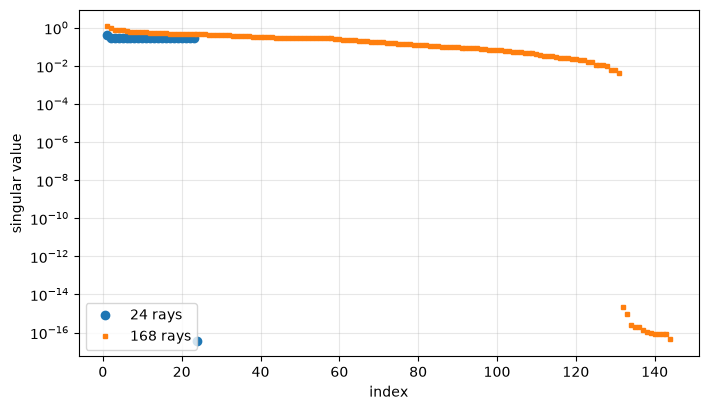

In [ ]:
edge = (np.arange(N) + 0.5) / N
rays2 = rays + [((0, a), (1, b)) for a in edge for b in edge]
G2 = ray_matrix(rays2, N)
U2, s2, Vt2 = np.linalg.svd(G2)
print(f"{len(rays2)} rays;  rank of G2 = {np.linalg.matrix_rank(G2)}")

fig, ax = plt.subplots()
ax.semilogy(np.arange(1, len(s) + 1), s, "o", label="24 rays")
ax.semilogy(np.arange(1, len(s2) + 1), s2, "s", ms=3, label="168 rays")
ax.set(xlabel="index", ylabel="singular value"); ax.legend()
plt.show()

Two things have happened. The rank has risen to 131, but not to 144: even 168 rays leave a 13-dimensional null space, because all the fan rays run broadly left to right and certain patterns of vertical variation are invisible to every one of them. And among the directions that *are* constrained, the singular values now span more than two orders of magnitude. The small ones correspond to model patterns that affect the data only weakly. In the inverse, those patterns are multiplied by $1/s_i$, so small errors in the data become large errors in the model. A problem with a wide range of singular values is **ill-conditioned**; for practical purposes it is still underdetermined, because real data always have errors.

To see this, add noise to the travel times and build the solution one singular vector at a time, from the best-constrained direction to the worst. Keeping the first $k$ terms is called **truncated SVD**:

$$
\hat{\mathbf{m}}_k = \mathbf{m}_0 + \sum_{i=1}^{k} \frac{\mathbf{u}_i^T(\mathbf{d} - \mathbf{G}\mathbf{m}_0)}{s_i}\,\mathbf{v}_i .
$$

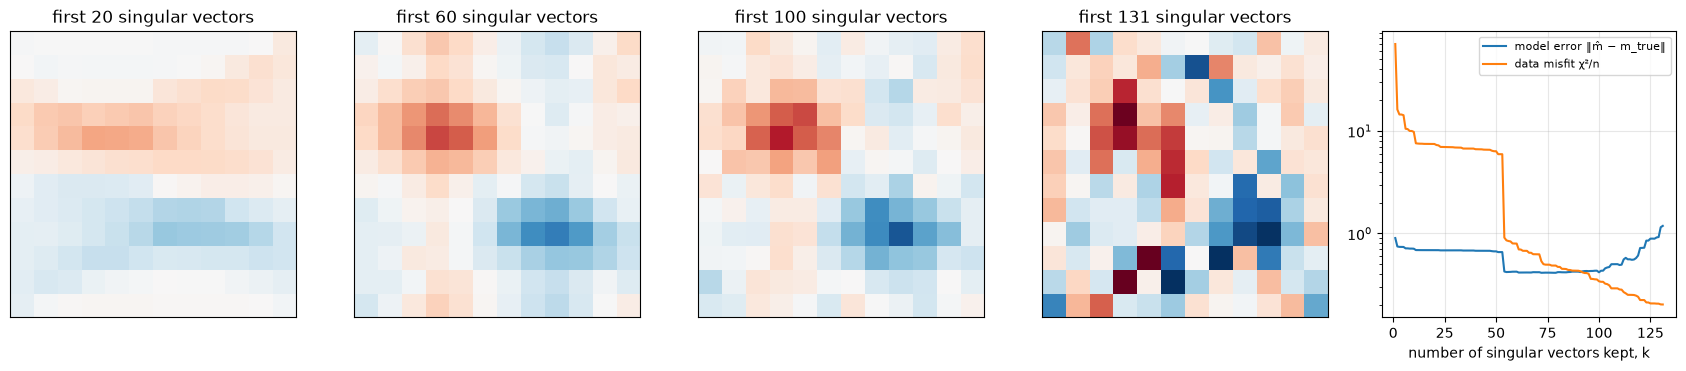

In [ ]:
sigma_d = 0.005                                                   # travel-time error, about 0.5% of a typical time
d_noisy = G2 @ m_true + stats.norm(0, sigma_d).rvs(len(rays2), random_state=rng)
rank2 = np.linalg.matrix_rank(G2)

coef = (U2.T @ (d_noisy - G2 @ m0))[:rank2] / s2[:rank2]         # coefficient of each singular vector
def tsvd(k):
    return m0 + Vt2[:k].T @ coef[:k]

ks = np.arange(1, rank2 + 1)
model_error = [np.linalg.norm(tsvd(k) - m_true) for k in ks]
data_misfit = [np.sum(((d_noisy - G2 @ tsvd(k)) / sigma_d)**2) for k in ks]

fig, ax = plt.subplots(1, 5, figsize=(17, 3.6))
for a, k in zip(ax[:4], [20, 60, 100, rank2]):
    show(tsvd(k), a, f"first {k} singular vectors", vmin=0.7, vmax=1.3)
ax[4].semilogy(ks, model_error, label="model error ‖m̂ − m_true‖")
ax[4].semilogy(ks, np.array(data_misfit) / len(d_noisy), label="data misfit χ²/n")
ax[4].set(xlabel="number of singular vectors kept, k"); ax[4].legend(fontsize=8)
plt.tight_layout(); plt.show()

Adding singular vectors first sharpens the image and then destroys it: beyond about a hundred terms the data misfit keeps falling but the model error rises, because the remaining terms are dominated by noise divided by small singular values. Fitting the data as well as possible is the *wrong* goal. The truncation point $k$ is a choice, and a different noise realisation would move it.

### Regularisation

The remedy is to give up fitting the data *exactly* and instead minimise a compromise between data misfit and model complexity:

$$
\chi^2(\mathbf{m}) + \lambda\,\|\mathbf{m} - \mathbf{m}_0\|^2, \qquad
\chi^2 = \sum_k \frac{(d_k - (\mathbf{G}\mathbf{m})_k)^2}{\sigma_k^2},
$$

whose minimiser is the **damped least-squares** (Tikhonov) solution

$$
\hat{\mathbf{m}} = \mathbf{m}_0 + \big(\mathbf{G}^T\mathbf{G} + \lambda\sigma_d^2\,\mathbf{I}\big)^{-1}\mathbf{G}^T(\mathbf{d} - \mathbf{G}\mathbf{m}_0).
$$

The **damping parameter** $\lambda$ controls the compromise. As $\lambda \to 0$ we recover the unstable pseudo-inverse; as $\lambda \to \infty$ we get the reference model regardless of data. In between, the damping suppresses the components along small singular values (each is multiplied by $s_i^2/(s_i^2 + \lambda\sigma_d^2)$) and so kills the amplified noise, at the cost of also suppressing any *real* structure in those directions. Choosing $\lambda$ is a judgement. A common rule, the **discrepancy principle**, is to take the smallest damping for which the data are fitted to within their errors, $\chi^2 \approx n$.

discrepancy principle picks λ ≈ 1.3e+03  (χ² = 177 for n = 168 data)


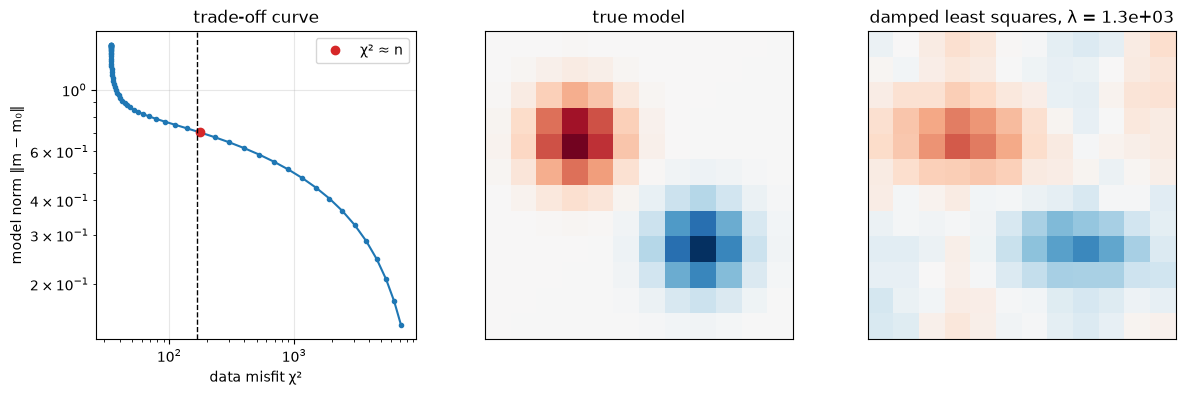

In [ ]:
def damped_ls(G, d, m0, sigma_d, lam):
    A = G.T @ G + lam * sigma_d**2 * np.eye(G.shape[1])
    return m0 + np.linalg.solve(A, G.T @ (d - G @ m0))

lams = np.logspace(-2, 5, 60)
chi2 = np.array([np.sum(((d_noisy - G2 @ damped_ls(G2, d_noisy, m0, sigma_d, l)) / sigma_d)**2) for l in lams])
norm = np.array([np.linalg.norm(damped_ls(G2, d_noisy, m0, sigma_d, l) - m0) for l in lams])

lam_star = lams[np.argmin(np.abs(chi2 - len(d_noisy)))]      # discrepancy principle
m_damped = damped_ls(G2, d_noisy, m0, sigma_d, lam_star)
print(f"discrepancy principle picks λ ≈ {lam_star:.2g}  (χ² = {np.sum(((d_noisy - G2 @ m_damped)/sigma_d)**2):.0f} for n = {len(d_noisy)} data)")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].loglog(chi2, norm, "o-", ms=3)
ax[0].plot(chi2[np.argmin(np.abs(chi2 - len(d_noisy)))], norm[np.argmin(np.abs(chi2 - len(d_noisy)))], "C3o", label="χ² ≈ n")
ax[0].axvline(len(d_noisy), color="k", lw=1, ls="--")
ax[0].set(xlabel="data misfit χ²", ylabel="model norm ‖m − m₀‖", title="trade-off curve"); ax[0].legend()
show(m_true, ax[1], "true model", vmin=0.7, vmax=1.3)
show(m_damped, ax[2], f"damped least squares, λ = {lam_star:.2g}", vmin=0.7, vmax=1.3)
plt.show()

The damped solution recovers the two anomalies, blurred and with reduced amplitude. The trade-off curve makes the compromise explicit: moving down it fits the data better with an ever larger, and eventually absurd, model. The knee of the curve, where the discrepancy principle lands, is the usual place to stop. Different choices of $\lambda$, or of what "complexity" means (the norm of the model, of its gradient, of its departure from some other reference), give different images from the same data. A tomographic image is not a photograph.

## Resolution: what does the estimate actually show?

Every linear estimate is a linear function of the data, $\hat{\mathbf{m}} - \mathbf{m}_0 = \mathbf{H}(\mathbf{d} - \mathbf{G}\mathbf{m}_0)$ for some matrix $\mathbf{H}$ (the pseudo-inverse, or the damped inverse above). For error-free data, $\mathbf{d} = \mathbf{G}\mathbf{m}_{\text{true}}$, and so

$$
\hat{\mathbf{m}} - \mathbf{m}_0 = \mathbf{R}\,(\mathbf{m}_{\text{true}} - \mathbf{m}_0), \qquad \mathbf{R} = \mathbf{H}\mathbf{G} .
$$

$\mathbf{R}$ is the **resolution matrix**. If it were the identity, the estimate would equal the truth. It never is, in an underdetermined problem: each row of $\mathbf{R}$ is a **resolving kernel** that says which weighted average of the true model the corresponding element of the estimate represents. The estimate is a *blurred* version of the truth, and $\mathbf{R}$ is the blur. This is computable, and it should be looked at.

A popular shortcut in tomography is the **checkerboard test**: put a checkerboard pattern through the whole procedure and see how much of it comes back. It amounts to looking at $\mathbf{R}$ applied to one particular model.

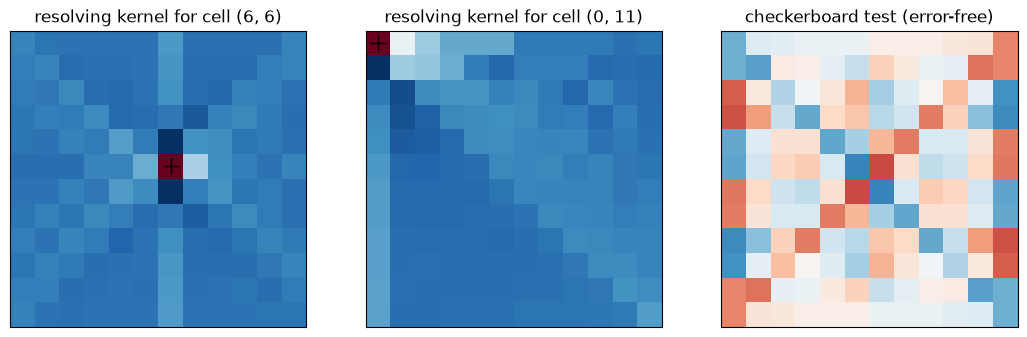

diagonal of R: mean 0.45 (1 would be perfect resolution);  trace of R = 64.8 'resolved parameters' out of 144


In [ ]:
H = np.linalg.solve(G2.T @ G2 + lam_star * sigma_d**2 * np.eye(M), G2.T)     # the damped inverse
R = H @ G2                                                                    # resolution matrix

fig, ax = plt.subplots(1, 3, figsize=(13, 4))
for a, cell in zip(ax[:2], [(6, 6), (0, 11)]):
    j = cell[0] + N * cell[1]
    show(R[j], a, f"resolving kernel for cell {cell}")
    a.plot((cell[0] + 0.5) / N, (cell[1] + 0.5) / N, "k+", ms=12)
checker = np.where(((X * N // 2).astype(int) + (Y * N // 2).astype(int)) % 2 == 0, 0.2, -0.2).ravel()
show(m0 + R @ checker, ax[2], "checkerboard test (error-free)", vmin=0.7, vmax=1.3)
plt.show()
print(f"diagonal of R: mean {np.mean(np.diag(R)):.2f} (1 would be perfect resolution);  trace of R = {np.trace(R):.1f} 'resolved parameters' out of {M}")

An interior cell is resolved as an average over a blob of neighbouring cells, elongated along the dominant ray direction. A corner cell, crossed by few rays, is resolved much more poorly. The trace of $\mathbf{R}$ counts the number of independent parameters the data really constrain at this level of damping, and it is a fraction of the 144 nominal unknowns. The checkerboard comes back blurred and attenuated, and worse near the edges.

Two warnings. Resolution says nothing about noise: a cell can be well resolved and still badly estimated if the data are poor. And the checkerboard test only tests checkerboards; a feature of a different shape or scale may be recovered better or worse.

## The Bayesian view: regularisation is a prior

Notebook 7 showed that multiplying a likelihood by a prior gives a posterior. Take a Gaussian prior for the model, centred on $\mathbf{m}_0$ with covariance $\mathbf{C}_m$, and Gaussian data errors with covariance $\mathbf{C}_d = \sigma_d^2\mathbf{I}$. The posterior is Gaussian, with

$$
\mathbf{C}_{\text{post}} = \big(\mathbf{G}^T\mathbf{C}_d^{-1}\mathbf{G} + \mathbf{C}_m^{-1}\big)^{-1}, \qquad
\hat{\mathbf{m}} = \mathbf{m}_0 + \mathbf{C}_{\text{post}}\,\mathbf{G}^T\mathbf{C}_d^{-1}(\mathbf{d} - \mathbf{G}\mathbf{m}_0).
$$

With $\mathbf{C}_m = \sigma_m^2\mathbf{I}$ the posterior mean is *exactly* the damped least-squares solution with $\lambda = 1/\sigma_m^2$. Damping is a prior in disguise: the damping parameter states how large you believe model perturbations to be. This is clarifying in two ways. First, it says what regularisation *means*, and lets you build in better information, such as spatial smoothness through correlations in $\mathbf{C}_m$. Second, the posterior covariance provides uncertainties and, better still, **samples**: a set of models each of which is consistent with the data *and* the prior. Their spread is the honest answer to "what do we know?"

Here we use a prior with smooth spatial correlations (nearby cells are likely to have similar slowness) and draw samples from the prior and the posterior.

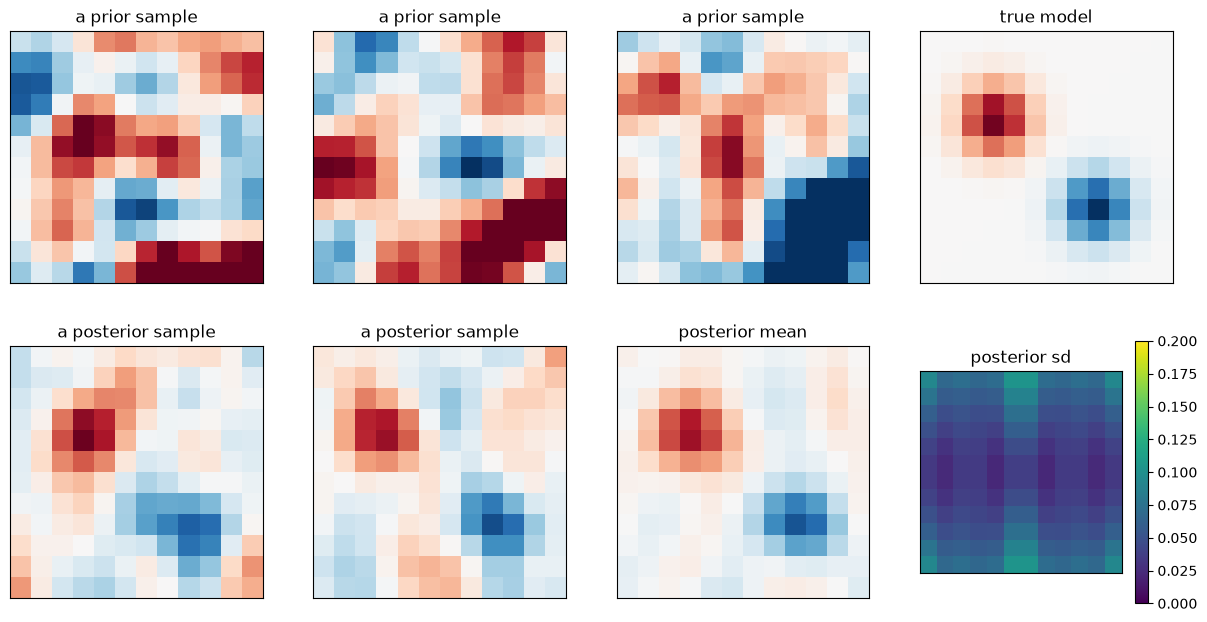

prior sd everywhere: 0.2;  posterior sd ranges from 0.023 (interior) to 0.104 (top and bottom edges)


In [ ]:
cells = np.column_stack([X.ravel(), Y.ravel()])
dist = np.linalg.norm(cells[:, None, :] - cells[None, :, :], axis=2)
sigma_m, ell = 0.2, 0.15                                            # prior amplitude and correlation length
C_m = sigma_m**2 * np.exp(-dist**2 / (2 * ell**2)) + 1e-8 * np.eye(M)

C_post = np.linalg.inv(G2.T @ G2 / sigma_d**2 + np.linalg.inv(C_m))
m_post = m0 + C_post @ G2.T @ (d_noisy - G2 @ m0) / sigma_d**2
std_post = np.sqrt(np.diag(C_post))

fig, ax = plt.subplots(2, 4, figsize=(15, 7.5))
for a in ax[0, :3]:
    show(rng.multivariate_normal(m0, C_m), a, "a prior sample", vmin=0.7, vmax=1.3)
show(m_true, ax[0, 3], "true model", vmin=0.7, vmax=1.3)
for a in ax[1, :2]:
    show(rng.multivariate_normal(m_post, C_post), a, "a posterior sample", vmin=0.7, vmax=1.3)
show(m_post, ax[1, 2], "posterior mean", vmin=0.7, vmax=1.3)
im = show(std_post, ax[1, 3], "posterior sd", vmin=0, vmax=sigma_m, cmap="viridis"); plt.colorbar(im, ax=ax[1, 3])
plt.show()
print(f"prior sd everywhere: {sigma_m};  posterior sd ranges from {std_post.min():.3f} (interior) to {std_post.max():.3f} (top and bottom edges)")

Prior samples are smooth random fields of the assumed amplitude and scale: what we thought plausible before looking at the data. Posterior samples all show the two anomalies, in roughly the right places, but differ in detail, particularly near the top and bottom edges where the fan rays are sparse and only the base rays pass: that is what the data leave undetermined. The posterior mean is the smooth compromise, and the standard deviation map shows where it can be trusted. Compare it with the resolving kernels above: the same geometry is at work.

The prior is doing real work here, and a different prior (larger amplitude, shorter correlation length) would give different posterior samples from the same data. That is not a defect of the method; it is the non-uniqueness of the inverse problem made explicit. The data alone do not determine the model, so something else must, and the Bayesian formulation forces you to say what.

## Optional: the same problem in function space with `pygeoinf`

The toy problem divided the block into 144 cells, so its null space had at most 144 dimensions. Really the unknown slowness is a *function* of position, and the null space is infinite-dimensional: there are infinitely many independent ways to change a function without changing a finite set of travel times. Working with functions directly needs a little more mathematics (Hilbert spaces of functions, and Gaussian measures on them, in place of vectors and covariance matrices), but the structure of the calculation is exactly as above.

There is an important conceptual difference, though. When we chopped the block into cells, the grid was *part of the model*: a 12 × 12 inversion and a 24 × 24 inversion of the same data are different problems with different answers, and nothing says which is right. In the function-space formulation the prior, the forward problem and the posterior are all defined for the function itself, with no grid anywhere, and the posterior is a mathematically well-defined object. A Fourier expansion is then only a *numerical approximation* to it. As the truncation degree is increased the computed mean, samples and uncertainties converge to something definite, and for a given prior one can work out in advance how many terms are needed: the library does this below, adding degrees until the last one carries less than one part in a million of the prior's expected energy. The number of parameters is a numerical resolution, chosen so that the answer is converged, not a modelling choice that changes the answer.

The Python library [`pygeoinf`](https://github.com/da380/pygeoinf), developed in this department, provides that machinery. Below we repeat the tomography experiment for a slowness function on a rectangular region, observed through straight rays between a set of sources and a set of receivers. Run the first cell to install the library if it is missing (it needs Python 3.12 or later, which Colab provides).

In Colab, the second cell shows two sliders for the numbers of sources and receivers; every source is connected to every receiver, so the number of rays is their product. The default of 12 and 12 gives 144 rays and runs in seconds. You can push it to 2,500 rays, but expect the later cells to take a few minutes at the top of the range. (Outside Colab the sliders do not appear; just edit the two numbers.)

truncation degree chosen for this prior: 64, giving 16384 coefficients
144 travel-time data


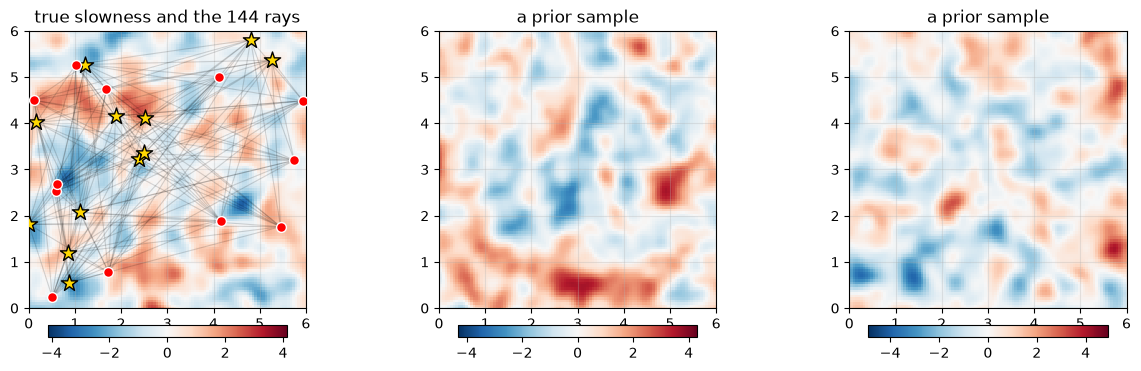

In [ ]:
try:
    import pygeoinf as inf
except ImportError:
    %pip install -q pygeoinf==1.8.9
    import pygeoinf as inf
from pygeoinf.symmetric_space.plane import Sobolev, plot, plot_geodesic_network
np.random.seed(1)                     # pygeoinf draws its samples from numpy's global generator

# The model space: functions on a 6 x 6 region (with a tapered margin of 0.5), smooth enough to be
# evaluated along rays. The prior is a Gaussian measure whose samples are smooth random fields with
# pointwise standard deviation 1; prior_scale sets their smoothness (features about half a unit across).
order, sobolev_scale, prior_scale = 2, 0.2, 0.1
model_space = Sobolev.from_heat_kernel_prior(prior_scale, order, sobolev_scale,
                                             ax=0.0, bx=6.0, cx=0.5, ay=0.0, by=6.0, cy=0.5,
                                             power_of_two=True, min_degree=32)
prior = model_space.point_value_scaled_heat_kernel_gaussian_measure(prior_scale)
print(f"truncation degree chosen for this prior: {model_space.degree}, giving {model_space.dim} coefficients")

# The forward problem: a ray from every source to every receiver. In Colab, use the sliders.
n_sources = 12    # @param {type:"slider", min:2, max:50, step:1}
n_receivers = 12  # @param {type:"slider", min:2, max:50, step:1}
sources, receivers = model_space.random_points(n_sources), model_space.random_points(n_receivers)
paths = [(src, rec) for src in sources for rec in receivers]
# The ray integrals are applied by non-uniform FFTs (matrix_free=True) rather than stored as a matrix,
# so thousands of rays cost little memory.
T = model_space.path_average_operator(paths, matrix_free=True)
tomo = inf.LinearForwardProblem(T, data_error_measure=inf.GaussianMeasure.from_standard_deviation(T.codomain, 0.05))
print(f"{len(paths)} travel-time data")

# A coarse-resolution copy of the ray operator, used below to build preconditioners
coarse = model_space.with_degree(model_space.degree // 4)
coarse_T = coarse.path_average_operator(paths)

# A true model drawn from the prior, and its noisy travel times
u_true, d = tomo.joint_measure(prior).sample()

fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
plot(model_space, u_true, ax=ax[0], symmetric=True, cmap="RdBu_r", colorbar=True)
plot_geodesic_network(paths, ax=ax[0], alpha=min(0.15, 30 / len(paths)), color="black"); ax[0].set_title(f"true slowness and the {len(paths)} rays")
for a in ax[1:]:
    plot(model_space, prior.sample(), ax=a, symmetric=True, cmap="RdBu_r", colorbar=True); a.set_title("a prior sample")
plt.show()

### The simplest function that fits the data

The minimum-norm solution now means the *smoothest* function (smallest norm in the chosen function space) whose predicted travel times fit the data to within their errors. Fitting exactly would be foolish with noisy data, so the library finds the smallest-norm function with $\chi^2$ at the 95% critical value: the discrepancy principle from earlier, built in. The search involves solving a linear system in data space several times over, and we solve each by conjugate gradients with a **preconditioner** built from the coarse copy of the ray operator; the same device is used for the Bayesian solution below, where it is explained.

χ² of the minimum-norm model = 173.0;  95% critical value for 144 data = 173.0


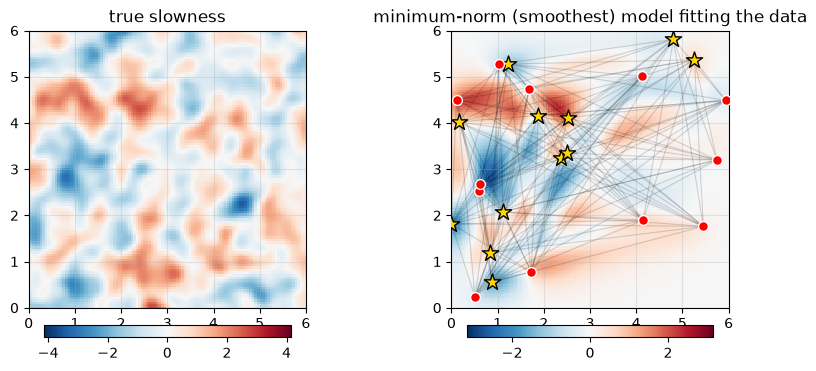

In [ ]:
chol = inf.CholeskySolver(galerkin=True)
precon_mn = inf.LinearLeastSquaresInversion(tomo).surrogate_woodbury_data_preconditioner(1.0, chol, alternate_forward_operator=coarse_T)
u_min = inf.LinearMinimumNormInversion(tomo).minimum_norm_operator(inf.CGMatrixSolver(), preconditioner=precon_mn)(d)
print(f"χ² of the minimum-norm model = {tomo.chi_squared(u_min, d):.1f};  95% critical value for {len(paths)} data = {tomo.critical_chi_squared(0.95):.1f}")

fig, ax = plt.subplots(1, 2, figsize=(10, 4.5))
plot(model_space, u_true, ax=ax[0], symmetric=True, cmap="RdBu_r", colorbar=True); ax[0].set_title("true slowness")
plot(model_space, u_min, ax=ax[1], symmetric=True, cmap="RdBu_r", colorbar=True)
plot_geodesic_network(paths, ax=ax[1], alpha=min(0.15, 30 / len(paths)), color="black"); ax[1].set_title("minimum-norm (smoothest) model fitting the data")
plt.show()

The smoothest data-fitting function captures the broad pattern where rays are dense and fades to zero (the reference) where they are not. It is a defensible choice, and no more than that.

### The Bayesian solution

With the prior above, the posterior is again Gaussian and we can draw samples from it, compute its mean, and map its pointwise standard deviation. The linear system to be solved has 16,384 unknowns, and the library solves it iteratively by conjugate gradients, helped by a **preconditioner** built from a coarse-resolution surrogate of the same problem. The preconditioner cuts the iteration count from hundreds to a handful, and since every posterior sample needs its own solve, that is what makes the uncertainty maps cheap; the same idea scales to problems with millions of unknowns.

posterior computed in 4 conjugate-gradient iterations


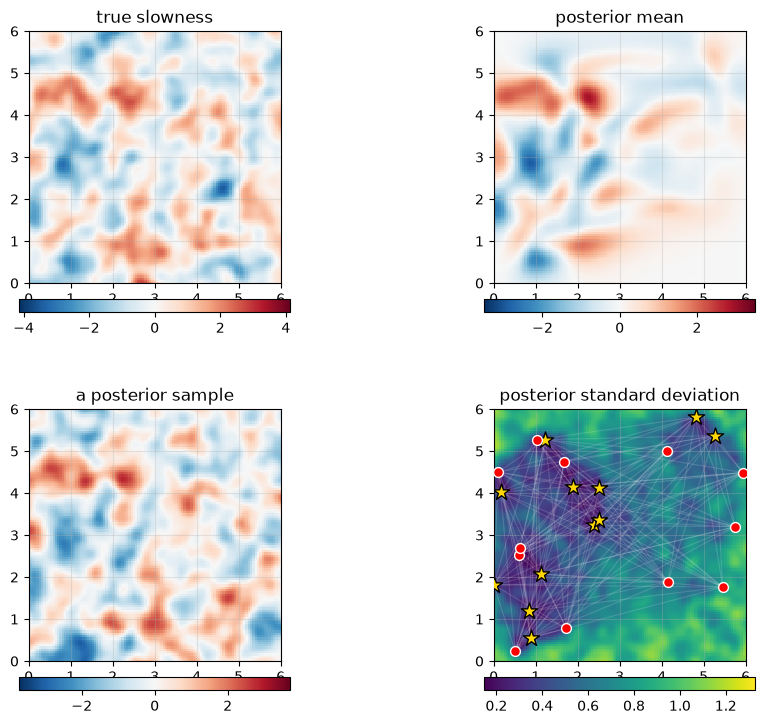

In [ ]:
inversion = inf.LinearBayesianInversion(tomo, prior)

# A surrogate Woodbury preconditioner built from the quarter-resolution copy of the problem
coarse_prior = coarse.point_value_scaled_heat_kernel_gaussian_measure(prior_scale)
precon = inversion.surrogate_inversion(
    alternate_forward_operator=coarse_T,
    alternate_prior_measure=coarse_prior.with_regularized_inverse(chol, damping=1e-6),
).woodbury_data_preconditioner(chol)
solver = inf.CGMatrixSolver()
posterior = inversion.model_posterior_measure(d, solver, preconditioner=precon)
print(f"posterior computed in {solver.iterations} conjugate-gradient iterations")

u_mean = posterior.expectation
u_std = posterior.sample_pointwise_std(50)

fig, ax = plt.subplots(2, 2, figsize=(11, 9))
plot(model_space, u_true, ax=ax[0, 0], symmetric=True, cmap="RdBu_r", colorbar=True); ax[0, 0].set_title("true slowness")
plot(model_space, u_mean, ax=ax[0, 1], symmetric=True, cmap="RdBu_r", colorbar=True); ax[0, 1].set_title("posterior mean")
plot(model_space, posterior.sample(), ax=ax[1, 0], symmetric=True, cmap="RdBu_r", colorbar=True); ax[1, 0].set_title("a posterior sample")
plot(model_space, u_std, ax=ax[1, 1], cmap="viridis", colorbar=True)
plot_geodesic_network(paths, ax=ax[1, 1], alpha=min(0.15, 30 / len(paths)), color="white"); ax[1, 1].set_title("posterior standard deviation")
plt.show()

This is the toy problem again, with all the same features: a mean that is a smoothed version of the truth, samples that agree where the rays are dense and wander where they are not, and a standard-deviation map that traces the ray coverage. Move the sliders up and rerun the cells from there to watch the posterior sharpen as the coverage improves. Three things have changed. The unknown now has 16,384 degrees of freedom against a few hundred data, so the null space is vast, and yet the calculation took seconds. Those 16,384 coefficients are a converged approximation to the posterior for the *function*: doubling the truncation degree would reproduce the same pictures, whereas doubling the number of cells in the toy problem gave a different problem. And nothing in the inversion code referred to the geometry: the lines that set up the prior, the forward problem and the posterior would be identical for slowness on a sphere observed by a global seismic network. That separation of the mathematics from the geometry is what the library is for. Its [tutorials](https://github.com/da380/pygeoinf/tree/main/tutorials) run the same tomography on a line, a circle, a torus, a plane and a sphere.

## Summary

- In an underdetermined problem the data fix only a few combinations of the model parameters; the null space, the set of models producing no data, contains everything else. Exact data do not help.
- The minimum-norm solution is the simplest data-fitting model in one specific sense. It is a choice.
- Small singular values amplify noise; damping (regularisation) trades data fit for model simplicity, and the trade-off curve makes the choice visible.
- The resolution matrix says which average of the truth each element of the estimate represents. Look at it.
- Regularisation is a prior. The Bayesian posterior gives uncertainties and samples that show what the data leave open.
- Posing the problem for the function itself, rather than for a grid of cells, gives a well-defined answer that numerical expansions merely approximate, and converge to.

**Further reading.** R. L. Parker, *Geophysical Inverse Theory* (Princeton), is the classic account of these ideas, and A. Tarantola, *Inverse Problem Theory* (SIAM, free online), the standard reference for the Bayesian view. The `pygeoinf` documentation at https://pygeoinf.readthedocs.io has worked examples on the line, circle, plane and sphere.

## Exercises

### Exercise 1

Return to the 24-ray experiment. Add a single diagonal ray from the bottom-left corner to the top-right corner. By how much does the rank increase? Now add the *other* diagonal. Then add rays from the bottom-left corner to each of the $N$ points on the right edge. Track the rank and the smallest non-zero singular value as rays are added, and explain why extra rays can raise the rank without making the problem much better determined in practice.

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
extra = [[((0, 0), (1, 1))],
         [((0, 0), (1, 1)), ((0, 1), (1, 0))],
         [((0, 0), (1, 1)), ((0, 1), (1, 0))] + [((0, 0), (1, b)) for b in edge]]
for e in extra:
    Ge = ray_matrix(rays + e, N)
    se = np.linalg.svd(Ge, compute_uv=False)
    r = np.linalg.matrix_rank(Ge)
    print(f"{len(rays) + len(e):3d} rays: rank {r:2d}, smallest non-zero singular value {se[r-1]:.3f}, largest {se[0]:.3f}")
```

Each diagonal adds one to the rank, and it is a healthy addition: the new singular value is as large as the existing ones, because a diagonal crosses many cells in a combination the row and column sums cannot form. The corner fan of twelve rays adds eleven more to the rank, but the smallest singular value drops by a factor of ten: those rays all pass through the same corner cells and differ from one another only slightly, so the new directions they constrain are constrained only weakly. Rank counts independent directions without regard to how *well* they are determined; the singular values are the honest measure, and they show that a handful of extra rays leaves the problem effectively underdetermined.

</details>

### Exercise 2

Repeat the damped least-squares inversion with the travel-time errors doubled (`sigma_d = 0.01`; regenerate the noisy data). Find the damping picked by the discrepancy principle, plot the trade-off curve and the recovered model, and compare the trace of the resolution matrix with the earlier value. What has the extra noise cost?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

```python
sd2 = 0.01
d2n = G2 @ m_true + stats.norm(0, sd2).rvs(len(rays2), random_state=rng)
chi2b = np.array([np.sum(((d2n - G2 @ damped_ls(G2, d2n, m0, sd2, l)) / sd2)**2) for l in lams])
lam2 = lams[np.argmin(np.abs(chi2b - len(d2n)))]
mb = damped_ls(G2, d2n, m0, sd2, lam2)
Rb = np.linalg.solve(G2.T @ G2 + lam2 * sd2**2 * np.eye(M), G2.T) @ G2
print(f"σ_d = {sd2}: λ = {lam2:.2g}, trace of R = {np.trace(Rb):.1f} (was {np.trace(R):.1f} with σ_d = {sigma_d})")
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
show(m_true, ax[0], "true model", vmin=0.7, vmax=1.3); show(mb, ax[1], f"damped LS, σ_d = {sd2}", vmin=0.7, vmax=1.3); plt.show()
```

Noisier data require heavier effective damping, the number of resolved parameters falls, and the recovered anomalies are blurrier and weaker. Resolution is not a property of the ray geometry alone; it depends on how good the data are.

</details>

### Exercise 3

In the `pygeoinf` tomography, the ray coverage and the prior are the two things that determine what the data can say. (a) Using the sliders, rerun the section with 4 sources and 4 receivers (16 rays) and then with 40 of each (1,600 rays); compare the minimum-norm models and the posterior standard-deviation maps. (b) Back at 12 and 12, halve and double the prior's scale parameter (the argument of `point_value_scaled_heat_kernel_gaussian_measure`, keeping the model space as it is), and see how the posterior mean and its uncertainty respond. In each case, where does the prior matter most?

In [ ]:
# Your code here

<details>
<summary><b>Solution</b> (click to expand)</summary>

For (a) the sliders do the work. With 16 rays the minimum-norm model is little more than a few smooth streaks along the rays, the posterior mean is much the same, and the uncertainty is close to the prior almost everywhere. With 1,600 rays the mean reproduces the truth in detail, and the uncertainty is small except in the margins, where rays are sparse.

For (b), the following reruns the inversion with the same rays and data-error level but a new prior each time:

```python
def invert(prior_scale, space=model_space):
    pr = space.point_value_scaled_heat_kernel_gaussian_measure(prior_scale)
    truth, data = tomo.joint_measure(pr).sample()
    inv = inf.LinearBayesianInversion(tomo, pr)
    pre = inv.surrogate_inversion(
        alternate_forward_operator=coarse_T,
        alternate_prior_measure=coarse.point_value_scaled_heat_kernel_gaussian_measure(prior_scale).with_regularized_inverse(chol, damping=1e-6),
    ).woodbury_data_preconditioner(chol)
    post = inv.model_posterior_measure(data, inf.CGMatrixSolver(), preconditioner=pre)
    return truth, post.expectation, post.sample_pointwise_std(30)

fig, ax = plt.subplots(2, 3, figsize=(15, 9))
for row, ps in zip(ax, [0.05, 0.2]):
    truth, mean, sd = invert(ps)
    plot(model_space, truth, ax=row[0], symmetric=True, cmap="RdBu_r", colorbar=True); row[0].set_title(f"truth, prior scale {ps}")
    plot(model_space, mean, ax=row[1], symmetric=True, cmap="RdBu_r", colorbar=True); row[1].set_title("posterior mean")
    plot(model_space, sd, ax=row[2], cmap="viridis", colorbar=True); row[2].set_title("posterior sd")
plt.show()
```

A small prior scale allows fine structure the rays cannot resolve, so the posterior stays uncertain between rays; a large one lets each ray constrain a broad neighbourhood, narrowing the posterior everywhere but at the risk of smoothing away real features. In every case the prior matters most where the ray coverage is poorest, which is exactly where the data leave the problem underdetermined.

</details>